In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
!pip -q install --upgrade xgboost imbalanced-learn shap

In [4]:
# ============================================================
# BLOCK 1 — SETUP
# ============================================================
# !pip -q install xgboost imbalanced-learn shap --upgrade

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import warnings, time
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    average_precision_score, roc_auc_score, brier_score_loss,
    make_scorer, precision_score, recall_score, roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# from google.colab import drive
# drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/DAI_DSE/dataset/dse_final_v3.csv"   # <-- adjust to your path
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values(["trading_code", "date"]).reset_index(drop=True)

print(f"Loaded {len(df):,} rows, {df['trading_code'].nunique()} tickers")
print(df["split"].value_counts())

Loaded 924,946 rows, 321 tickers
split
train    630356
test     294590
Name: count, dtype: int64


In [5]:
# ============================================================
# BLOCK 2 — FEATURES / TARGET
# ============================================================
ALL_FEATURES = [
    "daily_return","high_low_spread","intraday_volatility","volume_change_pct","price_gap",
    "rolling_5d_volatility","rolling_10d_momentum","ema_12",
    "macd","macd_signal","macd_hist","rsi_14","stoch_k","stoch_d","roc_10",
    "bb_width","atr_14","obv",
]

# XGBoost multi:softprob needs contiguous 0-indexed labels.
# Original classes {0: Normal, 1: High-Vol, 3: Crash} -> remap to {0, 1, 2}.
LABEL_MAP   = {0: 0, 1: 1, 3: 2}
CLASS_NAMES = {0: "Normal", 1: "High-Vol", 2: "Crash"}   # remapped space
CRASH_IDX   = 2

df["y"] = df["target_class"].map(LABEL_MAP)
assert df["y"].isnull().sum() == 0, "Unmapped target_class values found"

train_df = df[df["split"] == "train"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

X_train, y_train = train_df[ALL_FEATURES].values, train_df["y"].values.astype(int)
X_test,  y_test  = test_df[ALL_FEATURES].values,  test_df["y"].values.astype(int)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.round(np.bincount(y_train) / len(y_train), 4))
print("Test  class balance:", np.round(np.bincount(y_test) / len(y_test), 4))

Train: (630356, 18)  Test: (294590, 18)
Train class balance: [0.7383 0.206  0.0556]
Test  class balance: [0.7379 0.215  0.0471]


In [6]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 8.2 MB/s eta 0:00:00


In [7]:
# ============================================================
# BLOCK 3 — BASELINES (Reviewer 4: show ML's added value over trivial rules)
# ============================================================

# (a) Contemporaneous deterministic-rule check: class_same_day is defined
# directly by applying the labeling rule to the same day's raw values, so
# by construction it reproduces the rule with 100% accuracy. This is not
# a competing model — it's a sanity check that the label-generating rule
# itself is internally consistent, satisfying Reviewer 4's request for a
# deterministic-rule benchmark.
print("Contemporaneous rule check: class_same_day is generated directly from the")
print("labeling rule applied to same-day raw values, so it recovers itself with")
print("100% accuracy by construction. Included as a sanity check only, not a")
print("competing model — the real baselines below test t+1 FORECASTING ability.\n")

# (b) Naive persistence: predict tomorrow's class = today's realized class.
#     This is the real "does ML add value" baseline for the FORECASTING task.
persist_pred = test_df["class_same_day"].map(LABEL_MAP).values
persist_acc  = (persist_pred == y_test).mean()
persist_crash_recall = recall_score(y_test == CRASH_IDX, persist_pred == CRASH_IDX)
persist_crash_prec   = precision_score(y_test == CRASH_IDX, persist_pred == CRASH_IDX, zero_division=0)
print(f"[Naive persistence]      acc={persist_acc:.4f}  crash_recall={persist_crash_recall:.4f}  crash_precision={persist_crash_prec:.4f}")

# (c) Lagged-volatility rule: flag high-vol tomorrow if today's intraday
#     volatility exceeds its own train-period 80th percentile; else normal.
#     (Does not attempt to predict crash — crude one-variable heuristic.)
vol_thresh = train_df["intraday_volatility"].quantile(0.80)
lagvol_pred = np.where(test_df["intraday_volatility"] > vol_thresh, 1, 0)
lagvol_acc = (lagvol_pred == y_test).mean()
print(f"[Lagged-volatility rule] acc={lagvol_acc:.4f}  (single-variable heuristic, no crash class)")

# (d) Logistic regression with the same lagged features — a real statistical
#     baseline (not just a rule), multiclass, class-weighted.
logreg = LogisticRegression(max_iter=2000, class_weight="balanced",
                             multi_class="multinomial", random_state=RANDOM_STATE)
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)
print(f"[Logistic regression]    acc={ (logreg_pred==y_test).mean():.4f}  "
      f"crash_PR-AUC={average_precision_score(y_test==CRASH_IDX, logreg_proba[:,CRASH_IDX]):.4f}")

# (e) GARCH(1,1)-based volatility-regime baseline (optional, simplified).
# A full per-stock GARCH fit across 321 tickers is expensive; this is a
# lightweight pooled-index approximation for benchmarking purposes only —
# flag this simplification explicitly in the paper if you keep it.
try:
    from arch import arch_model
    pooled_returns = train_df.groupby("date")["daily_return"].mean().dropna()
    garch = arch_model(pooled_returns, vol="Garch", p=1, q=1, rescale=False)
    garch_fit = garch.fit(disp="off")
    print("\n[GARCH(1,1) pooled-index] fitted — see garch_fit.summary() for details")
    print(garch_fit.summary().tables[1])
except ImportError:
    print("\n[GARCH] 'arch' package not installed — run `!pip install arch` if you want this baseline")

Contemporaneous rule check: class_same_day is generated directly from the
labeling rule applied to same-day raw values, so it recovers itself with
100% accuracy by construction. Included as a sanity check only, not a
competing model — the real baselines below test t+1 FORECASTING ability.

[Naive persistence]      acc=0.7262  crash_recall=0.1737  crash_precision=0.1736
[Lagged-volatility rule] acc=0.7447  (single-variable heuristic, no crash class)
[Logistic regression]    acc=0.6765  crash_PR-AUC=0.1222

[GARCH(1,1) pooled-index] fitted — see garch_fit.summary() for details
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
------------------------------------------------------------------------------
mu            -0.0184  8.080e-03     -2.279  2.269e-02 [-3.425e-02,-2.575e-03]


In [8]:
# ============================================================
# BLOCK 4 — EXPANDING-WINDOW WALK-FORWARD CV, WITH EMBARGO
# ============================================================
def make_expanding_folds(dates_sorted_unique, n_folds=5, embargo_days=5):
    """
    Expanding-window folds over unique trading dates. Fold k trains on all
    dates before its validation block (expanding), validates on a forward
    contiguous block. An embargo of `embargo_days` is dropped immediately
    before each validation window to reduce leakage from serially-correlated
    rolling-window features/labels near the boundary (Lopez de Prado-style
    purging) — answers Reviewer 4's nested CV / purging-embargo request.
    """
    n = len(dates_sorted_unique)
    fold_size = n // (n_folds + 1)
    folds = []
    for k in range(1, n_folds + 1):
        val_start = k * fold_size
        val_end   = min((k + 1) * fold_size, n)
        if val_start >= n or val_end <= val_start:
            continue
        train_end = max(val_start - embargo_days, 1)
        folds.append((dates_sorted_unique[:train_end], dates_sorted_unique[val_start:val_end]))
    return folds

unique_train_dates = np.sort(train_df["date"].unique())
FOLDS_DATES = make_expanding_folds(unique_train_dates, n_folds=5, embargo_days=5)

train_dates_arr = train_df["date"].values
cv_splits = []
for i, (tr_d, va_d) in enumerate(FOLDS_DATES):
    tr_idx = np.where(np.isin(train_dates_arr, tr_d))[0]
    va_idx = np.where(np.isin(train_dates_arr, va_d))[0]
    cv_splits.append((tr_idx, va_idx))
    print(f"Fold {i+1}: train {pd.Timestamp(tr_d[0]).date()}->{pd.Timestamp(tr_d[-1]).date()} "
          f"({len(tr_idx):,} rows) | val {pd.Timestamp(va_d[0]).date()}->{pd.Timestamp(va_d[-1]).date()} "
          f"({len(va_idx):,} rows)")

Fold 1: train 2008-04-03->2010-01-11 (81,245 rows) | val 2010-01-19->2011-11-02 (90,671 rows)
Fold 2: train 2008-04-03->2011-10-26 (171,846 rows) | val 2011-11-03->2013-09-02 (97,570 rows)
Fold 3: train 2008-04-03->2013-08-25 (269,311 rows) | val 2013-09-03->2015-06-17 (109,249 rows)
Fold 4: train 2008-04-03->2015-06-10 (378,385 rows) | val 2015-06-18->2017-03-21 (121,398 rows)
Fold 5: train 2008-04-03->2017-03-14 (499,703 rows) | val 2017-03-22->2018-12-20 (127,959 rows)


In [9]:
# ============================================================
# BLOCK 5-LR — LOGISTIC REGRESSION PIPELINES, LEAK-SAFE SCALING
# StandardScaler is placed INSIDE the pipeline so it's fit fresh on each
# CV fold's training slice only — fitting it globally on X_train before
# CV would leak fold-level information into the scaler's mean/std.
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sample_weight_full = compute_sample_weight("balanced", y_train)

# Strategy A: class weighting via sample_weight, passed through the
# pipeline step name ("logreg__sample_weight") so GridSearchCV routes it
# correctly to the final estimator, not the scaler.
logreg_weighted = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        multi_class="multinomial", random_state=RANDOM_STATE, max_iter=1000
    ))
])

# Strategy B: SMOTE inside an imblearn Pipeline, applied AFTER scaling but
# still only on the training fold — validation/test folds pass through
# untouched, same leak-safe guarantee as the tree models.
logreg_smote = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("logreg", LogisticRegression(
        multi_class="multinomial", random_state=RANDOM_STATE, max_iter=1000
    ))
])

print("Built logreg_weighted (scaled + sample_weight) and logreg_smote (scaled + SMOTE-in-fold).")

Built logreg_weighted (scaled + sample_weight) and logreg_smote (scaled + SMOTE-in-fold).


In [10]:
# ============================================================
# BLOCK 6 (fixed) — SCORER: crash-class PR-AUC is the primary tuning target
# needs_proba was deprecated/removed in newer scikit-learn in favor of
# response_method="predict_proba" — same effect, current API.
# ============================================================
def crash_pr_auc(y_true, y_proba):
    y_bin = (y_true == CRASH_IDX).astype(int)
    return average_precision_score(y_bin, y_proba[:, CRASH_IDX])

crash_scorer = make_scorer(crash_pr_auc, response_method="predict_proba")

def macro_pr_auc(y_true, y_proba):
    return np.mean([average_precision_score((y_true == c).astype(int), y_proba[:, c])
                     for c in range(3)])

macro_scorer = make_scorer(macro_pr_auc, response_method="predict_proba")

print("Scorers rebuilt with response_method='predict_proba' (current sklearn API).")

Scorers rebuilt with response_method='predict_proba' (current sklearn API).


In [11]:
# ============================================================
# BLOCK 7-LR — STAGED RANDOMIZED SEARCH
# Stage 1: C (regularization strength) with lbfgs/L2 — fast solver.
# Stage 2: penalty/solver comparison (L1 vs L2 vs elasticnet via saga) —
# saga is slower, so this stage uses fewer candidates and a capped max_iter.
# Total: (6+4) candidates x 5 folds = 50 fits — small by design; Logistic
# Regression has far fewer meaningful hyperparameters than a tree ensemble,
# so an exhaustive/large search here would not be a productive use of
# compute budget (stated explicitly as the Reviewer 3 justification).
# ============================================================
from sklearn.model_selection import RandomizedSearchCV

N_FOLDS_USED = cv_splits[:5]

def run_stage_lr(stage_name, pipeline, param_distributions, n_iter, fit_params=None):
    gs = RandomizedSearchCV(
        pipeline, param_distributions, n_iter=n_iter,
        scoring=crash_scorer, cv=N_FOLDS_USED, n_jobs=1,
        refit=False, random_state=RANDOM_STATE, verbose=1
    )
    t0 = time.time()
    gs.fit(X_train, y_train, **(fit_params or {}))
    print(f"\n[{stage_name}] best crash-PR-AUC={gs.best_score_:.4f}  "
          f"best_params={gs.best_params_}  ({time.time()-t0:.0f}s, "
          f"{n_iter} candidates x {len(N_FOLDS_USED)} folds = {n_iter*len(N_FOLDS_USED)} fits)")
    return gs.best_params_, gs

# Stage 1: C, with L2/lbfgs fixed (fast, reliable solver)
stage1_params, gs1_lr = run_stage_lr(
    "Stage 1 - C (L2/lbfgs)",
    logreg_weighted,
    {"logreg__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
     "logreg__penalty": ["l2"],
     "logreg__solver": ["lbfgs"]},
    n_iter=6,
    fit_params={"logreg__sample_weight": sample_weight_full}
)

# Stage 2: penalty/solver comparison around the best C from Stage 1, using saga
# (saga is slower per-fit but supports l1/elasticnet, needed to actually compare)
best_C = stage1_params["logreg__C"]
stage2_params, gs2_lr = run_stage_lr(
    "Stage 2 - penalty/solver (saga)",
    logreg_weighted,
    {"logreg__C": [best_C * 0.5, best_C, best_C * 2],
     "logreg__penalty": ["l1", "l2", "elasticnet"],
     "logreg__solver": ["saga"],
     "logreg__l1_ratio": [0.5]},   # only used when penalty="elasticnet", ignored otherwise
    n_iter=4,
    fit_params={"logreg__sample_weight": sample_weight_full}
)

best_params_lr = {**stage1_params, **stage2_params}
print("\n=== FINAL BEST PARAMS (class-weighted Logistic Regression) ===")
print(best_params_lr)

Fitting 5 folds for each of 6 candidates, totalling 30 fits

[Stage 1 - C (L2/lbfgs)] best crash-PR-AUC=0.1194  best_params={'logreg__solver': 'lbfgs', 'logreg__penalty': 'l2', 'logreg__C': 100.0}  (191s, 6 candidates x 5 folds = 30 fits)
Fitting 5 folds for each of 4 candidates, totalling 20 fits

[Stage 2 - penalty/solver (saga)] best crash-PR-AUC=0.1193  best_params={'logreg__solver': 'saga', 'logreg__penalty': 'l2', 'logreg__l1_ratio': 0.5, 'logreg__C': 50.0}  (3519s, 4 candidates x 5 folds = 20 fits)

=== FINAL BEST PARAMS (class-weighted Logistic Regression) ===
{'logreg__solver': 'saga', 'logreg__penalty': 'l2', 'logreg__C': 50.0, 'logreg__l1_ratio': 0.5}


In [12]:
# ============================================================
# BLOCK 8-LR — CV FOLD-LEVEL METRICS WITH FINAL TUNED PARAMS
# ============================================================
final_solver_lr = best_params_lr.get("logreg__solver", "lbfgs")
final_penalty_lr = best_params_lr.get("logreg__penalty", "l2")
final_C_lr = best_params_lr.get("logreg__C", 1.0)
final_l1_ratio_lr = best_params_lr.get("logreg__l1_ratio", None)

def build_final_logreg():
    kwargs = dict(C=final_C_lr, penalty=final_penalty_lr, solver=final_solver_lr,
                   multi_class="multinomial", random_state=RANDOM_STATE, max_iter=2000)
    if final_penalty_lr == "elasticnet":
        kwargs["l1_ratio"] = final_l1_ratio_lr
    return kwargs

fold_metrics_lr = []
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train[tr_idx])
    X_va_scaled = scaler.transform(X_train[va_idx])

    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])
    model = LogisticRegression(**build_final_logreg())
    model.fit(X_tr_scaled, y_train[tr_idx], sample_weight=fold_weights)

    proba = model.predict_proba(X_va_scaled)
    pred  = proba.argmax(axis=1)
    y_va  = y_train[va_idx]

    fold_metrics_lr.append({
        "fold": i + 1,
        "crash_pr_auc": crash_pr_auc(y_va, proba),
        "macro_pr_auc": macro_pr_auc(y_va, proba),
        "crash_recall": recall_score(y_va == CRASH_IDX, pred == CRASH_IDX),
        "crash_precision": precision_score(y_va == CRASH_IDX, pred == CRASH_IDX, zero_division=0),
        "roc_auc_ovr": roc_auc_score(y_va, proba, multi_class="ovr"),
    })

fold_df_lr = pd.DataFrame(fold_metrics_lr).set_index("fold")
print(fold_df_lr.round(4))
print("\nMean ± Std across folds:")
print((fold_df_lr.mean().round(4).astype(str) + " ± " + fold_df_lr.std().round(4).astype(str)))

      crash_pr_auc  macro_pr_auc  crash_recall  crash_precision  roc_auc_ovr
fold                                                                        
1           0.1655        0.4655        0.3784           0.1856       0.7060
2           0.1366        0.4634        0.2787           0.1495       0.6952
3           0.1054        0.4579        0.1941           0.1142       0.7185
4           0.0914        0.4545        0.1640           0.1154       0.7516
5           0.1037        0.4560        0.2128           0.1135       0.7486

Mean ± Std across folds:
crash_pr_auc       0.1205 ± 0.0302
macro_pr_auc       0.4595 ± 0.0048
crash_recall       0.2456 ± 0.0853
crash_precision    0.1356 ± 0.0318
roc_auc_ovr         0.724 ± 0.0253
dtype: object


=== Classification report (test set, 2019-2022) — Logistic Regression ===
              precision    recall  f1-score   support

      Normal     0.8606    0.7777    0.8170    217365
    High-Vol     0.4228    0.4645    0.4426     63344
       Crash     0.1250    0.2573    0.1683     13881

    accuracy                         0.6858    294590
   macro avg     0.4695    0.4998    0.4760    294590
weighted avg     0.7318    0.6858    0.7060    294590



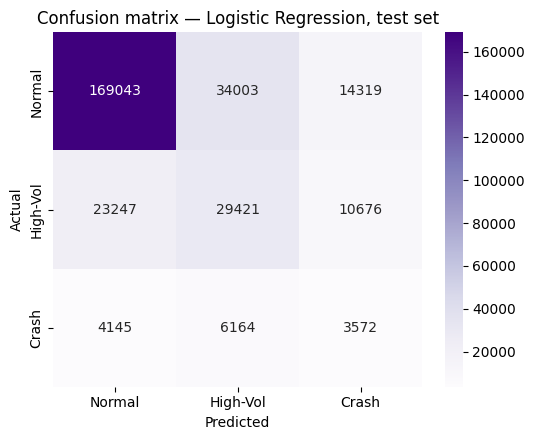


Crash-class PR-AUC : 0.1270
Macro PR-AUC       : 0.4952
ROC-AUC (OvR)      : 0.7717


In [13]:
# ============================================================
# BLOCK 9-LR — FINAL MODEL: fit scaler + model on full train, evaluate on test
# ============================================================
scaler_final_lr = StandardScaler()
X_train_scaled = scaler_final_lr.fit_transform(X_train)
X_test_scaled  = scaler_final_lr.transform(X_test)

final_model_lr = LogisticRegression(**build_final_logreg())
final_model_lr.fit(X_train_scaled, y_train, sample_weight=sample_weight_full)

test_proba_lr = final_model_lr.predict_proba(X_test_scaled)
test_pred_lr  = test_proba_lr.argmax(axis=1)

print("=== Classification report (test set, 2019-2022) — Logistic Regression ===")
print(classification_report(y_test, test_pred_lr, target_names=[CLASS_NAMES[c] for c in range(3)], digits=4))

cm_lr = confusion_matrix(y_test, test_pred_lr)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Purples",
            xticklabels=[CLASS_NAMES[c] for c in range(3)],
            yticklabels=[CLASS_NAMES[c] for c in range(3)])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion matrix — Logistic Regression, test set")
plt.tight_layout(); plt.show()

print(f"\nCrash-class PR-AUC : {crash_pr_auc(y_test, test_proba_lr):.4f}")
print(f"Macro PR-AUC       : {macro_pr_auc(y_test, test_proba_lr):.4f}")
print(f"ROC-AUC (OvR)      : {roc_auc_score(y_test, test_proba_lr, multi_class='ovr'):.4f}")

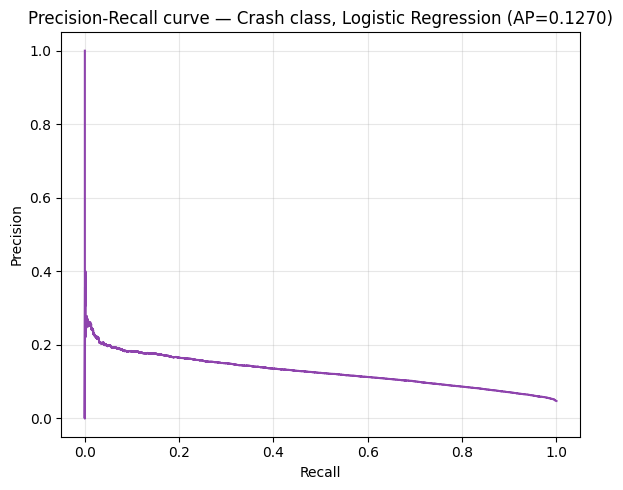

Recall @ FPR<=5%: 0.1995  (threshold=0.4415)
Precision@top-50 alerts: 0.3600
Precision@top-100 alerts: 0.2300
Precision@top-500 alerts: 0.2560
Precision@top-1000 alerts: 0.2400

Event-level crash recall (±1 day tolerance): 0.5363  (11471 distinct crash episodes)


In [14]:
# ============================================================
# BLOCK 10-LR — PR CURVE, OPERATIONAL METRICS, EVENT-LEVEL DETECTION
# ============================================================
prec_lr, rec_lr, thresh_lr = precision_recall_curve(y_test == CRASH_IDX, test_proba_lr[:, CRASH_IDX])

plt.figure(figsize=(6, 5))
plt.plot(rec_lr, prec_lr, color="#8e44ad")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision-Recall curve — Crash class, Logistic Regression "
          f"(AP={average_precision_score(y_test==CRASH_IDX, test_proba_lr[:,CRASH_IDX]):.4f})")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

fpr_lr, tpr_lr, roc_thresh_lr = roc_curve(y_test == CRASH_IDX, test_proba_lr[:, CRASH_IDX])
target_fpr = 0.05
idx = np.searchsorted(fpr_lr, target_fpr, side="right") - 1
idx = max(idx, 0)
print(f"Recall @ FPR<={target_fpr:.0%}: {tpr_lr[idx]:.4f}  (threshold={roc_thresh_lr[idx]:.4f})")

for k in [50, 100, 500, 1000]:
    top_k_idx = np.argsort(-test_proba_lr[:, CRASH_IDX])[:k]
    prec_at_k = (y_test[top_k_idx] == CRASH_IDX).mean()
    print(f"Precision@top-{k} alerts: {prec_at_k:.4f}")

# Event-level detection: group consecutive per-stock crash rows into
# discrete "episodes" and check whether the model raised at least one
# alert within a +/-1 trading-day tolerance window of each episode —
# row-level recall alone over-penalizes multi-day crash streaks that are
# really one event (Reviewer 4's event-level ask).
def event_level_recall(test_df, y_test, test_pred, tolerance=1):
    tdf = test_df.copy()
    tdf["y_true"] = y_test
    tdf["y_pred"] = test_pred
    tdf = tdf.sort_values(["trading_code", "date"]).reset_index(drop=True)

    detected, total_events = 0, 0
    for code, g in tdf.groupby("trading_code"):
        g = g.reset_index(drop=True)
        is_crash = (g["y_true"] == CRASH_IDX).values
        # identify contiguous crash episodes
        episode_id = (is_crash != np.roll(is_crash, 1)).cumsum() * is_crash
        for eid in np.unique(episode_id[episode_id > 0]):
            idxs = np.where(episode_id == eid)[0]
            total_events += 1
            lo, hi = max(idxs[0]-tolerance, 0), min(idxs[-1]+tolerance, len(g)-1)
            if (g["y_pred"].iloc[lo:hi+1] == CRASH_IDX).any():
                detected += 1
    return detected / total_events if total_events else np.nan, total_events

ev_recall_lr, n_events_lr = event_level_recall(test_df, y_test, test_pred_lr, tolerance=1)
print(f"\nEvent-level crash recall (±1 day tolerance): {ev_recall_lr:.4f}  ({n_events_lr} distinct crash episodes)")

Brier score (crash)                       : 0.08317
Brier score, prevalence-only baseline     : 0.04490
Brier Skill Score vs. prevalence baseline : -0.8523


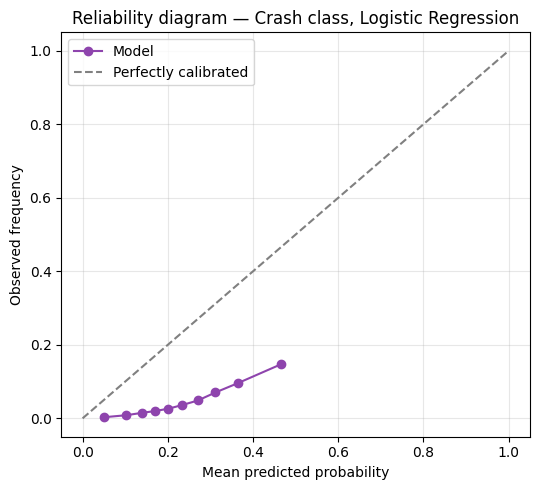


Expected Calibration Error (crash): 0.1841


In [15]:
# ============================================================
# BLOCK 11-LR — CALIBRATION DIAGNOSTICS
# ============================================================
y_crash_true = (y_test == CRASH_IDX).astype(int)
p_crash_lr = test_proba_lr[:, CRASH_IDX]

brier_lr = brier_score_loss(y_crash_true, p_crash_lr)
prevalence = y_crash_true.mean()
brier_baseline = brier_score_loss(y_crash_true, np.full_like(p_crash_lr, prevalence))
brier_skill_score_lr = 1 - (brier_lr / brier_baseline)

print(f"Brier score (crash)                       : {brier_lr:.5f}")
print(f"Brier score, prevalence-only baseline     : {brier_baseline:.5f}")
print(f"Brier Skill Score vs. prevalence baseline : {brier_skill_score_lr:.4f}")

frac_pos_lr, mean_pred_lr = calibration_curve(y_crash_true, p_crash_lr, n_bins=10, strategy="quantile")
plt.figure(figsize=(5.5, 5))
plt.plot(mean_pred_lr, frac_pos_lr, marker="o", color="#8e44ad", label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.xlabel("Mean predicted probability"); plt.ylabel("Observed frequency")
plt.title("Reliability diagram — Crash class, Logistic Regression")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(p_crash_lr, bins) - 1
ece_lr = 0.0
for b in range(10):
    mask = bin_ids == b
    if mask.sum() == 0: continue
    ece_lr += (mask.sum() / len(p_crash_lr)) * abs(y_crash_true[mask].mean() - p_crash_lr[mask].mean())
print(f"\nExpected Calibration Error (crash): {ece_lr:.4f}")

In [16]:
# ============================================================
# BLOCK 12-LR — REGIME-SPECIFIC PERFORMANCE
# ============================================================

REGIMES = {
    "Pre-COVID (2019)":        ("2019-01-01", "2020-02-29"),
    "COVID crash":              ("2020-03-01", "2020-05-31"),
    "Post-COVID recovery":      ("2020-06-01", "2021-12-31"),
    "Russia-Ukraine (2022)":    ("2022-02-24", "2022-12-31"),
}

test_df_eval_lr = test_df.copy()
test_df_eval_lr["y_true"] = y_test
test_df_eval_lr["y_pred"] = test_pred_lr
test_df_eval_lr["p_crash"] = test_proba_lr[:, CRASH_IDX]

regime_rows_lr = []
for name, (start, end) in REGIMES.items():
    mask = (test_df_eval_lr["date"] >= start) & (test_df_eval_lr["date"] <= end)
    sub = test_df_eval_lr[mask]
    if len(sub) == 0:
        continue
    y_true_r, y_pred_r, p_r = sub["y_true"], sub["y_pred"], sub["p_crash"]
    regime_rows_lr.append({
        "regime": name, "n_rows": len(sub),
        "crash_rate": (y_true_r == CRASH_IDX).mean(),
        "crash_recall": recall_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_precision": precision_score(y_true_r == CRASH_IDX, y_pred_r == CRASH_IDX, zero_division=0),
        "crash_pr_auc": average_precision_score(y_true_r == CRASH_IDX, p_r) if (y_true_r==CRASH_IDX).sum() > 0 else np.nan,
    })

regime_df_lr = pd.DataFrame(regime_rows_lr).set_index("regime")
print(regime_df_lr.round(4))

                       n_rows  crash_rate  crash_recall  crash_precision  \
regime                                                                     
Pre-COVID (2019)        88242      0.0523        0.2360           0.1227   
COVID crash              6099      0.2289        0.3832           0.2713   
Post-COVID recovery    123425      0.0472        0.2427           0.1087   
Russia-Ukraine (2022)   64780      0.0262        0.2792           0.1187   

                       crash_pr_auc  
regime                               
Pre-COVID (2019)             0.1207  
COVID crash                  0.2864  
Post-COVID recovery          0.1125  
Russia-Ukraine (2022)        0.1221  


LOGISTIC REGRESSION COEFFICIENTS (crash class, scaled features)
                  feature  coef_crash  label_adjacent
16                 atr_14     0.45788           False
13                stoch_d    -0.42141           False
12                stoch_k     0.37236           False
1         high_low_spread    -0.22278           False
2     intraday_volatility     0.21312            True
5   rolling_5d_volatility     0.20330           False
0            daily_return    -0.11718            True
6    rolling_10d_momentum    -0.11366           False
3       volume_change_pct    -0.09944           False
14                 roc_10     0.08318           False
15               bb_width     0.07253           False
10              macd_hist     0.06318           False
11                 rsi_14     0.06310           False
8                    macd    -0.04460           False
7                  ema_12    -0.04032           False
9             macd_signal     0.01473           False
17                


PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test set) — Logistic Regression
                  feature  importance_mean  importance_std  label_adjacent
13                stoch_d          0.04601         0.00052           False
16                 atr_14          0.04046         0.00051           False
12                stoch_k          0.03820         0.00063           False
2     intraday_volatility          0.03799         0.00047            True
5   rolling_5d_volatility          0.03793         0.00046           False
0            daily_return          0.01245         0.00032            True
1         high_low_spread          0.00891         0.00036           False
14                 roc_10          0.00469         0.00024           False
11                 rsi_14          0.00373         0.00022           False
15               bb_width          0.00329         0.00016           False
6    rolling_10d_momentum          0.00307         0.00026           False
3       volume_cha

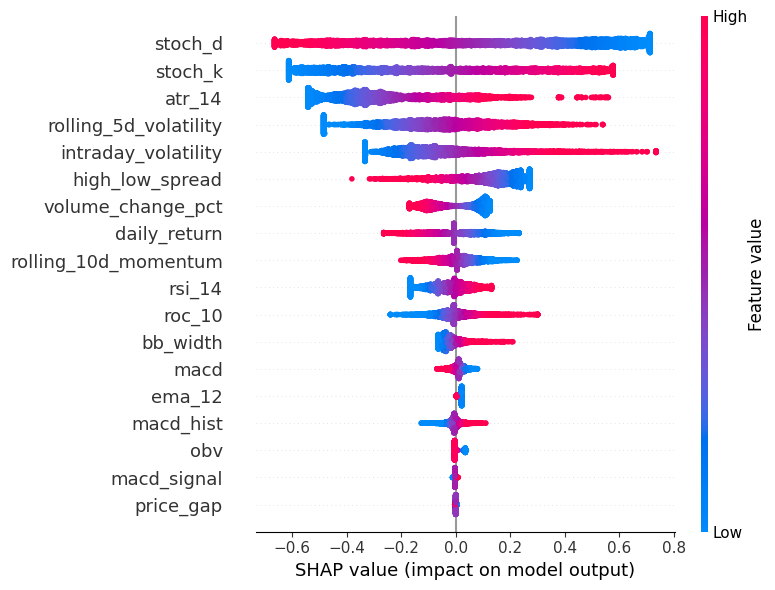


LABEL-ADJACENT FEATURE CONTRIBUTION CHECK — Logistic Regression
Full model crash PR-AUC                              : 0.1270
Excl. daily_return/intraday_volatility, crash PR-AUC : 0.1117


In [17]:
# ============================================================
# BLOCK 13-LR — COEFFICIENTS, PERMUTATION IMPORTANCE, SHAP (LINEAR)
# ============================================================
LABEL_ADJACENT = ["daily_return", "intraday_volatility"]

# ------------------------------------------------------------
# Raw coefficients (crash class), most directly interpretable for a linear model
# ------------------------------------------------------------
coef_df = pd.DataFrame({
    "feature": ALL_FEATURES,
    "coef_crash": final_model_lr.coef_[CRASH_IDX],
    "label_adjacent": [f in LABEL_ADJACENT for f in ALL_FEATURES]
}).sort_values("coef_crash", key=abs, ascending=False)
print("="*70)
print("LOGISTIC REGRESSION COEFFICIENTS (crash class, scaled features)")
print("="*70)
print(coef_df.round(5))

# ------------------------------------------------------------
# Permutation importance (out-of-sample, on scaled test features)
# ------------------------------------------------------------
perm_lr = permutation_importance(final_model_lr, X_test_scaled, y_test, scoring=crash_scorer,
                                  n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df_lr = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance_mean": perm_lr.importances_mean,
    "importance_std": perm_lr.importances_std,
    "label_adjacent": [f in LABEL_ADJACENT for f in ALL_FEATURES]
}).sort_values("importance_mean", ascending=False)
print("\n" + "="*70)
print("PERMUTATION IMPORTANCE (crash-class PR-AUC drop, test set) — Logistic Regression")
print("="*70)
print(perm_df_lr.round(5))

# ------------------------------------------------------------
# SHAP (LinearExplainer — appropriate for linear models, faster than KernelExplainer)
# ------------------------------------------------------------
background = X_train_scaled[np.random.choice(len(X_train_scaled), 1000, replace=False)]
explainer_lr = shap.LinearExplainer(final_model_lr, background)
shap_values_lr = explainer_lr.shap_values(X_test_scaled[:5000])

if isinstance(shap_values_lr, list):
    shap_values_crash_lr = shap_values_lr[CRASH_IDX]
else:
    shap_values_crash_lr = shap_values_lr[:, :, CRASH_IDX] if shap_values_lr.ndim == 3 else shap_values_lr

print("\nSHAP values shape (crash class):", shap_values_crash_lr.shape)
shap.summary_plot(shap_values_crash_lr, X_test_scaled[:5000], feature_names=ALL_FEATURES,
                   show=True, plot_size=(8, 6))

# ------------------------------------------------------------
# Companion model excluding label-adjacent features
# ------------------------------------------------------------
ALT_FEATURES = [f for f in ALL_FEATURES if f not in LABEL_ADJACENT]
scaler_alt = StandardScaler()
X_train_alt_scaled = scaler_alt.fit_transform(train_df[ALT_FEATURES].values)
X_test_alt_scaled  = scaler_alt.transform(test_df[ALT_FEATURES].values)

alt_model_lr = LogisticRegression(**build_final_logreg())
alt_model_lr.fit(X_train_alt_scaled, y_train, sample_weight=sample_weight_full)
alt_proba_lr = alt_model_lr.predict_proba(X_test_alt_scaled)

print("\n" + "="*70)
print("LABEL-ADJACENT FEATURE CONTRIBUTION CHECK — Logistic Regression")
print("="*70)
print(f"Full model crash PR-AUC                              : {crash_pr_auc(y_test, test_proba_lr):.4f}")
print(f"Excl. daily_return/intraday_volatility, crash PR-AUC : {crash_pr_auc(y_test, alt_proba_lr):.4f}")

In [18]:
# ============================================================
# BLOCK 14-LR — SMOTE VARIANT: same CV, same scorer, for direct comparison
# ============================================================
smote_param_grid_lr = {
    "logreg__C": [final_C_lr],
    "logreg__penalty": [final_penalty_lr],
    "logreg__solver": [final_solver_lr],
}
if final_penalty_lr == "elasticnet":
    smote_param_grid_lr["logreg__l1_ratio"] = [final_l1_ratio_lr]

gs_smote_lr = GridSearchCV(logreg_smote, smote_param_grid_lr, scoring=crash_scorer,
                            cv=cv_splits, n_jobs=1, refit=True, verbose=1)
gs_smote_lr.fit(X_train, y_train)

smote_test_proba_lr = gs_smote_lr.predict_proba(X_test)
print(f"\n[SMOTE variant]        crash PR-AUC (test): {crash_pr_auc(y_test, smote_test_proba_lr):.4f}")
print(f"[Class-weight variant] crash PR-AUC (test): {crash_pr_auc(y_test, test_proba_lr):.4f}")

print("\nSMOTE resampling report (Logistic Regression):")
print("  Original class counts:", np.bincount(y_train))

Fitting 5 folds for each of 1 candidates, totalling 5 fits

[SMOTE variant]        crash PR-AUC (test): 0.1251
[Class-weight variant] crash PR-AUC (test): 0.1270

SMOTE resampling report (Logistic Regression):
  Original class counts: [465423 129879  35054]


In [19]:
# ============================================================
# BLOCK 15-LR — SUMMARY TABLE
# ============================================================
summary_lr = pd.DataFrame({
    "Model": ["Logistic Regression (class-weighted)", "Logistic Regression (SMOTE)"],
    "Crash PR-AUC": [
        crash_pr_auc(y_test, test_proba_lr),
        crash_pr_auc(y_test, smote_test_proba_lr),
    ],
    "Crash Recall": [
        recall_score(y_test==CRASH_IDX, test_pred_lr==CRASH_IDX),
        recall_score(y_test==CRASH_IDX, smote_test_proba_lr.argmax(axis=1)==CRASH_IDX),
    ],
})
print(summary_lr.round(4))

                                  Model  Crash PR-AUC  Crash Recall
0  Logistic Regression (class-weighted)        0.1270        0.2573
1           Logistic Regression (SMOTE)        0.1251        0.2683


1. CLASSIFICATION REPORT (test set, 2019-2022) — Logistic Regression
              precision  recall  f1-score      support
Normal           0.8606  0.7777    0.8170  217365.0000
High-Vol         0.4228  0.4645    0.4426   63344.0000
Crash            0.1250  0.2573    0.1683   13881.0000
accuracy         0.6858  0.6858    0.6858       0.6858
macro avg        0.4695  0.4998    0.4760  294590.0000
weighted avg     0.7318  0.6858    0.7060  294590.0000

2. CROSS-VALIDATION REPORT (mean ± std across folds) — Logistic Regression
              precision_mean  precision_std  recall_mean  recall_std  \
class_metric                                                           
Crash                 0.1356         0.0318       0.2456      0.0853   
High-Vol              0.3847         0.0292       0.3839      0.0174   
Normal                0.8350         0.0509       0.7849      0.0656   
accuracy              0.6791         0.0814       0.6791      0.0814   
macro avg             0.4518         0

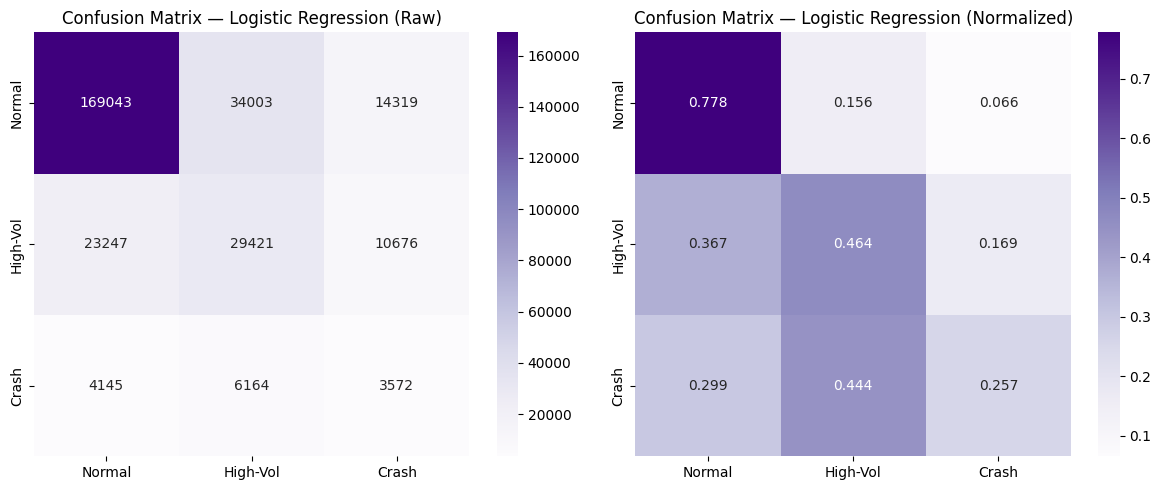

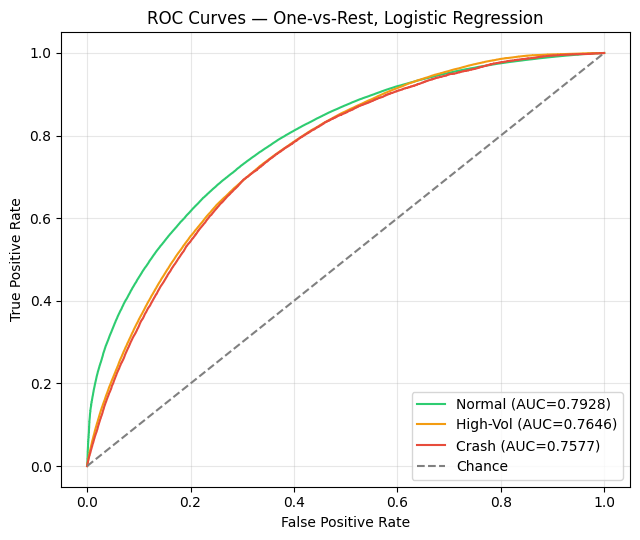


REPORT COMPLETE — LOGISTIC REGRESSION


In [22]:
# ============================================================
# BLOCK 16-LR — FINAL COMPREHENSIVE REPORT
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

CLASS_ORDER = [0, 1, 2]
CLASS_LABELS_LIST = [CLASS_NAMES[c] for c in CLASS_ORDER]

print("="*70)
print("1. CLASSIFICATION REPORT (test set, 2019-2022) — Logistic Regression")
print("="*70)
report_dict_lr = classification_report(y_test, test_pred_lr, target_names=CLASS_LABELS_LIST,
                                        digits=4, output_dict=True)
print(pd.DataFrame(report_dict_lr).T.round(4))

print("\n" + "="*70)
print("2. CROSS-VALIDATION REPORT (mean ± std across folds) — Logistic Regression")
print("="*70)
per_fold_reports_lr = []
for i, (tr_idx, va_idx) in enumerate(cv_splits):
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_train[tr_idx])
    X_va_scaled = scaler.transform(X_train[va_idx])
    fold_weights = compute_sample_weight("balanced", y_train[tr_idx])
    model = LogisticRegression(**build_final_logreg())
    model.fit(X_tr_scaled, y_train[tr_idx], sample_weight=fold_weights)
    va_pred = model.predict(X_va_scaled)
    y_va = y_train[va_idx]
    rep = classification_report(y_va, va_pred, target_names=CLASS_LABELS_LIST,
                                 digits=4, output_dict=True, zero_division=0)
    rep_df = pd.DataFrame(rep).T
    rep_df["fold"] = i + 1
    per_fold_reports_lr.append(rep_df)

all_folds_df_lr = pd.concat(per_fold_reports_lr).reset_index().rename(columns={"index": "class_metric"})
cv_summary_lr = all_folds_df_lr.groupby("class_metric")[["precision", "recall", "f1-score", "support"]].agg(["mean", "std"])
cv_summary_lr.columns = ["_".join(c) for c in cv_summary_lr.columns]
print(cv_summary_lr.round(4))

cm_raw_lr = confusion_matrix(y_test, test_pred_lr)
cm_norm_lr = confusion_matrix(y_test, test_pred_lr, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_raw_lr, annot=True, fmt="d", cmap="Purples",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[0])
axes[0].set_title("Confusion Matrix — Logistic Regression (Raw)")
sns.heatmap(cm_norm_lr, annot=True, fmt=".3f", cmap="Purples",
            xticklabels=CLASS_LABELS_LIST, yticklabels=CLASS_LABELS_LIST, ax=axes[1])
axes[1].set_title("Confusion Matrix — Logistic Regression (Normalized)")
plt.tight_layout(); plt.show()

y_test_bin = label_binarize(y_test, classes=CLASS_ORDER)
plt.figure(figsize=(6.5, 5.5))
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
for i, c in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], test_proba_lr[:, i])
    roc_auc_c = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], label=f"{CLASS_NAMES[c]} (AUC={roc_auc_c:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — One-vs-Rest, Logistic Regression")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\n" + "="*70)
print("REPORT COMPLETE — LOGISTIC REGRESSION")
print("="*70)